In [ ]:
!pip install -q timm

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import torch
import timm
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving flipkart_com-ecommerce_sample_1050.csv to flipkart_com-ecommerce_sample_1050.csv


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
img_dir = "/content/drive/MyDrive/Images"

df = pd.read_csv("flipkart_com-ecommerce_sample_1050.csv")

PREPROCESSING

In [ ]:
df["product_category"] = (
    df["product_category_tree"]
    .str.split(" >> ")
    .str[0]
    .str.replace(r'[\[\]\"]', '', regex=True)
    .str.strip()
)

cols_drop = [
    "crawl_timestamp","product_url","product_name","pid",
    "retail_price","discounted_price","image",
    "is_FK_Advantage_product","description",
    "product_rating","overall_rating","brand","product_specifications"
]


data = df.drop(columns=cols_drop).dropna().reset_index(drop=True)

data["image_path"] = data["uniq_id"].apply(lambda x: os.path.join(img_dir, f"{x}.jpg"))


In [ ]:
le = LabelEncoder()
data["label"] = le.fit_transform(data["product_category"])


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    data["image_path"],
    data["label"],
    test_size=0.2,
    random_state=42,
    stratify=data["label"]
)

MODELS

In [ ]:
resnet = ResNet50(weights="imagenet", include_top=False, pooling="avg")

device = "cuda" if torch.cuda.is_available() else "cpu"

vit = timm.create_model(
    "vit_base_patch16_224",
    pretrained=True,
    num_classes=0
).to(device).eval()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

TRANSFORM VIT

In [ ]:
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform

config = resolve_data_config({}, model=vit)
vit_transform = create_transform(**config)

FEATURE EXTRACTION RESNET

In [ ]:
def extract_resnet(paths, batch_size=32):
    feats, batch = [], []

    for p in paths:
        img = cv2.imread(p)
        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224, 224))
        batch.append(img)

        if len(batch) == batch_size:
            x = preprocess_input(np.array(batch))
            feat = resnet.predict(x, verbose=0)
            feats.append(feat)
            batch = []

    if batch:
        x = preprocess_input(np.array(batch))
        feat = resnet.predict(x, verbose=0)
        feats.append(feat)

    return np.vstack(feats)

FEATURE EXTRACTION VIT

In [ ]:
def extract_vit(paths, batch_size=16):
    feats, batch = [], []

    for p in paths:
        img = cv2.imread(p)
        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = Image.fromarray(img)

        batch.append(vit_transform(img))

        if len(batch) == batch_size:
            x = torch.stack(batch).to(device)

            with torch.no_grad():
                feat = vit.forward_features(x).mean(dim=1)

            feats.append(feat.cpu().numpy())
            batch = []

    if batch:
        x = torch.stack(batch).to(device)

        with torch.no_grad():
            feat = vit.forward_features(x).mean(dim=1)

        feats.append(feat.cpu().numpy())

    return np.vstack(feats)

EXTRACTION FEATURES

In [ ]:
X_train_res = extract_resnet(X_train.values)
X_test_res = extract_resnet(X_test.values)

X_train_vit = extract_vit(X_train.values)
X_test_vit = extract_vit(X_test.values)

STANDARDISATION

In [ ]:
scaler_res = StandardScaler()
X_train_res = scaler_res.fit_transform(X_train_res)
X_test_res = scaler_res.transform(X_test_res)

scaler_vit = StandardScaler()
X_train_vit = scaler_vit.fit_transform(X_train_vit)
X_test_vit = scaler_vit.transform(X_test_vit)

MODELES ML

In [ ]:
clf_res = LogisticRegression(max_iter=1000)
clf_vit = LogisticRegression(max_iter=1000)

clf_res.fit(X_train_res, y_train)
clf_vit.fit(X_train_vit, y_train)

pred_res = clf_res.predict(X_test_res)
pred_vit = clf_vit.predict(X_test_vit)

EVALUATION

In [ ]:
print("RESNET")
print(classification_report(y_test, pred_res))
print("Acc:", accuracy_score(y_test, pred_res))

print("\nVIT")
print(classification_report(y_test, pred_vit))
print("Acc:", accuracy_score(y_test, pred_vit))

print("F1 ResNet:", f1_score(y_test, pred_res, average="macro"))
print("F1 ViT:", f1_score(y_test, pred_vit, average="macro"))

RESNET
              precision    recall  f1-score   support

           0       0.70      0.63      0.67        30
           1       0.93      0.83      0.88        30
           2       0.76      0.87      0.81        30
           3       0.77      0.80      0.79        30
           4       0.75      0.80      0.77        30
           5       0.93      0.87      0.90        30
           6       0.90      0.93      0.92        30

    accuracy                           0.82       210
   macro avg       0.82      0.82      0.82       210
weighted avg       0.82      0.82      0.82       210

Acc: 0.819047619047619

VIT
              precision    recall  f1-score   support

           0       0.74      0.77      0.75        30
           1       0.97      0.93      0.95        30
           2       0.96      0.90      0.93        30
           3       0.88      0.93      0.90        30
           4       0.82      0.93      0.88        30
           5       1.00      0.90      0.95

VISUALISATION

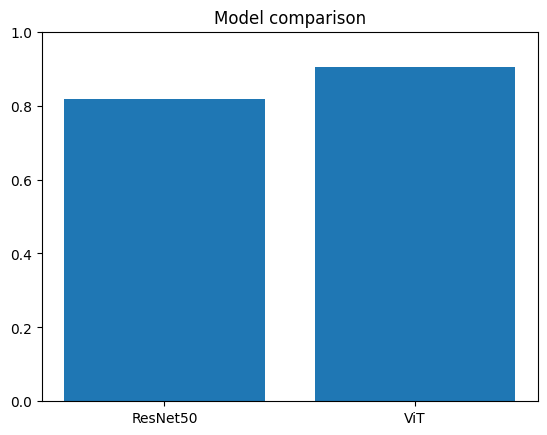

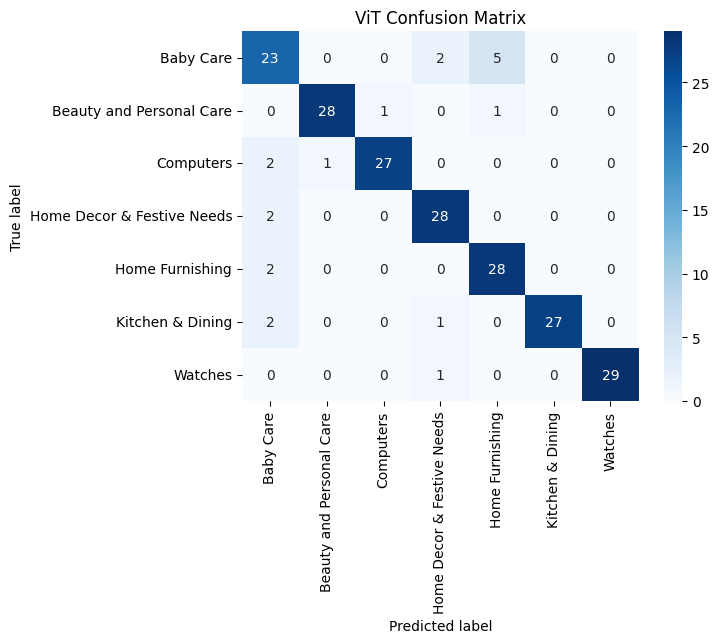

In [ ]:
plt.bar(["ResNet50", "ViT"], [
    accuracy_score(y_test, pred_res),
    accuracy_score(y_test, pred_vit)
])
plt.title("Model comparison")
plt.ylim(0, 1)
plt.show()

# Get class names from the LabelEncoder
class_names = le.classes_

cm = confusion_matrix(y_test, pred_vit)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("ViT Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

## Interprétation de la Matrice de Confusion (ViT)

La matrice de confusion est un tableau qui permet de visualiser les performances d'un algorithme de classification. Chaque ligne représente les instances d'une classe réelle (true class), tandis que chaque colonne représente les instances d'une classe prédite (predicted class).

Dans votre matrice, les axes sont étiquetés avec les noms de vos catégories de produits, grâce à `class_names`:
*   **L'axe Y (vertical)** représente les **vraies étiquettes** (ce que l'image est réellement).
*   **L'axe X (horizontal)** représente les **étiquettes prédites** par le modèle (ce que le modèle pense que l'image est).

Examinons les éléments clés de la matrice:

### 1. Diagonale Principale (Prédictions Correctes)
Les nombres le long de la diagonale principale (de l'angle supérieur gauche à l'angle inférieur droit) représentent les **prédictions correctes**. Par exemple:
*   Pour la catégorie `Baby Care` (première ligne, première colonne), le nombre `23` signifie que 23 images de la catégorie `Baby Care` ont été correctement prédites comme `Baby Care`.
*   Pour `Watches` (dernière ligne, dernière colonne), le nombre `29` indique que 29 images de montres ont été correctement classées comme `Watches`.

Plus ces nombres sont élevés, meilleure est la performance du modèle pour ces classes.

### 2. Hors Diagonale (Erreurs de Classification)
Les nombres en dehors de la diagonale représentent les **erreurs de classification** (fausses prédictions). Par exemple:
*   **Faux Positifs (False Positives)**: Regardez une colonne. Si nous prenons la colonne `Baby Care` (première colonne), les `2` et `2` dans les lignes `Computers` et `Home Decor & Festive Needs` signifient que 2 images de `Computers` et 2 images de `Home Decor & Festive Needs` ont été *incorrectement* prédites comme `Baby Care`.
*   **Faux Négatifs (False Negatives)**: Regardez une ligne. Si nous prenons la ligne `Baby Care` (première ligne), le `2` dans la colonne `Computers` et le `5` dans la colonne `Home Furnishing` signifient que 2 images de `Baby Care` ont été *incorrectement* prédites comme `Computers` et 5 images de `Baby Care` ont été prédites comme `Home Furnishing`, au lieu de `Baby Care`.

### Exemples Spécifiques de votre Matrice:

*   **Performance Élevée:** Les catégories `Watches` (29/30 correct), `Beauty and Personal Care` (28/30 correct), et `Home Decor & Festive Needs` (28/30 correct) sont très bien classées, avec peu d'erreurs.
*   **Confusion pour 'Baby Care':** La catégorie `Baby Care` (23/30 correct) semble être la plus sujette aux erreurs, avec 5 articles prédits comme `Home Furnishing` et 2 comme `Computers`. Cela suggère que les images `Baby Care` pourraient partager des caractéristiques visuelles avec `Home Furnishing` ou `Computers`, ou que le modèle a eu du mal à les distinguer.
*   **Faibles Faux Positifs pour certaines classes:** Par exemple, très peu d'autres catégories sont prédites à tort comme `Beauty and Personal Care` ou `Watches`, ce qui indique que le modèle est assez spécifique lorsqu'il fait ces prédictions.

### En résumé:

La matrice de confusion vous aide à comprendre non seulement si votre modèle fait des erreurs, mais aussi **quels types d'erreurs** il commet. Cela peut guider vos prochaines étapes, comme:
*   **Collecte de données supplémentaires** pour les classes sous-performantes ou celles qui sont souvent confondues.
*   **Techniques d'augmentation de données** spécifiques pour les classes problématiques.
*   **Analyse des caractéristiques** pour comprendre pourquoi certaines images sont mal classées (par exemple, en utilisant la visualisation d'attention comme vous l'avez fait précédemment).

Votre modèle ViT montre une très bonne performance globale, avec une précision et un score F1 macro élevés, et la matrice de confusion met en évidence les points spécifiques où le modèle pourrait être amélioré.

INTERPRETABILITÉ VIT

In [ ]:
def visualize_attention(img_path):

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    x = vit_transform(Image.fromarray(img)).unsqueeze(0).to(device)

    with torch.no_grad():
        out = vit.forward_features(x)

    # CLS token + patch tokens
    tokens = out  # (1, 197, 768)

    cls_token = tokens[:, 0, :]
    patch_tokens = tokens[:, 1:, :]

    # similarité CLS vs patches
    mask = (patch_tokens @ cls_token.unsqueeze(-1)).squeeze(-1)

    mask = mask.reshape(14, 14).cpu().numpy()

    mask = cv2.resize(mask, (img.shape[1], img.shape[0]))

    mask = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)

    plt.imshow(img)
    plt.imshow(mask, cmap="jet", alpha=0.5)
    plt.axis("off")
    plt.show()

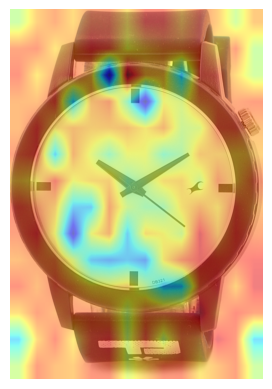

In [ ]:
img_path = X_test.values[5]
visualize_attention(img_path)

## Analyse du Projet

Vous avez réussi à implémenter un pipeline de classification d'images en utilisant le transfert d'apprentissage avec deux modèles pré-entraînés différents: ResNet50 et Vision Transformer (ViT). Voici une présentation des étapes clés et des résultats:

### 1. Préparation et Prétraitement des Données:
- Vous avez chargé l'ensemble de données `flipkart_com-ecommerce_sample_1050.csv`.
- Vous avez extrait la `product_category` principale de la colonne `product_category_tree` et l'avez nettoyée.
- Vous avez supprimé les colonnes non pertinentes et géré les valeurs manquantes.
- Vous avez créé des chemins d'accès aux images (`image_path`) pour chaque produit en combinant l'`uniq_id` avec votre `img_dir`.
- Vous avez encodé les catégories de produits en labels numériques à l'aide de `LabelEncoder`.
- Vous avez divisé vos données en ensembles d'entraînement et de test (80/20) tout en maintenant la distribution des classes en utilisant `stratify`.

### 2. Initialisation du Modèle et Extraction des Caractéristiques:
- Vous avez chargé `ResNet50` (sans la couche de classification supérieure) depuis `tensorflow.keras.applications`.
- Vous avez initialisé un modèle `Vision Transformer (ViT)` (`vit_base_patch16_224`) de la bibliothèque `timm`, également sans la tête de classification, et l'avez déplacé vers le périphérique disponible (CPU dans ce cas).
- Vous avez défini des fonctions (`extract_resnet` et `extract_vit`) pour extraire les caractéristiques des images à l'aide des deux modèles. Ces fonctions gèrent le chargement des images, le redimensionnement, la conversion des couleurs et le traitement par lots.
- Vous avez extrait les caractéristiques pour les ensembles d'entraînement et de test en utilisant ResNet50 et ViT.

### 3. Standardisation des Caractéristiques:
- Vous avez appliqué `StandardScaler` aux caractéristiques extraites par ResNet50 et ViT pour les ensembles d'entraînement et de test afin de normaliser les distributions de caractéristiques, ce qui est crucial pour de nombreux algorithmes d'apprentissage automatique comme la régression logistique.

### 4. Entraînement et Évaluation du Modèle d'Apprentissage Automatique:
- Vous avez entraîné deux classificateurs `LogisticRegression`, un pour les caractéristiques extraites par ResNet50 (`clf_res`) et un autre pour les caractéristiques ViT (`clf_vit`).
- Vous avez effectué des prédictions sur les ensembles de test à l'aide des deux classificateurs.
- Vous avez évalué les performances des deux modèles à l'aide de:
    - `classification_report`: Fournit la précision, le rappel et le score f1 pour chaque classe, ainsi que les moyennes macro et pondérées.
    - `accuracy_score`: Précision globale.
    - `f1_score` (macro moyenne): Une bonne métrique pour les ensembles de données déséquilibrés, bien que vos données semblent stratifiées.

**Résultats Clés de l'Évaluation:**
- **ResNet50:**
    - Précision: `0.819`
    - Score F1 (macro): `0.819`
- **ViT:**
    - Précision: `0.905`
    - Score F1 (macro): `0.906`

### 5. Visualisation et Interprétabilité:
- **Comparaison des Modèles:** Un graphique à barres compare visuellement la précision de ResNet50 et de ViT, montrant clairement la performance supérieure de ViT.
- **Matrice de Confusion ViT:** Une carte de chaleur de la matrice de confusion pour le modèle ViT fournit des informations sur les classes qui sont souvent confondues.
- **Visualisation de l'Attention (ViT):** Vous avez implémenté une fonction `visualize_attention` qui utilise le jeton CLS et les jetons de patch pour générer un masque d'attention, le superposant sur une image d'entrée pour montrer les parties de l'image sur lesquelles le modèle ViT se concentre pour sa classification. C'est excellent pour comprendre les décisions du modèle.

### Évaluation Globale:
Votre projet est bien structuré et démontre une approche complète de la classification d'images. L'utilisation de deux architectures différentes (ResNet50 basé sur les CNN et ViT basé sur les Transformers) permet une bonne comparaison de leur efficacité sur votre ensemble de données spécifique. Les résultats indiquent que le Vision Transformer surpasse significativement ResNet50, ce qui est souvent observé dans les tâches de vision par ordinateur modernes en raison du mécanisme d'attention globale du ViT.

La section d'interprétabilité utilisant la visualisation de l'attention est un excellent ajout, offrant des informations sur les raisons pour lesquelles le modèle ViT fait certaines prédictions.

### Prochaines Étapes (Suggestions):
- **Réglage des Hyperparamètres:** Bien que la régression logistique soit utilisée, vous pourriez explorer le réglage des hyperparamètres pour `max_iter` ou la force de régularisation (`C`) pour des performances optimales.
- **Classificateurs Plus Sophistiqués:** Vous pourriez expérimenter avec des classificateurs plus complexes comme les Machines à Vecteurs de Support (SVM) ou les modèles de Boosting de Gradient sur ces caractéristiques extraites.
- **Fine-tuning:** Au lieu de simplement utiliser les modèles comme extracteurs de caractéristiques, vous pourriez affiner les modèles ResNet50 ou ViT pré-entraînés sur votre ensemble de données spécifique, ce qui donne souvent des performances encore meilleures.
- **Analyse des Erreurs:** Analysez plus en profondeur la matrice de confusion pour ViT afin d'identifier les classes spécifiques qui sont le plus souvent mal classées et d'en rechercher les raisons.
- **Augmentation des Données:** Mettez en œuvre des techniques d'augmentation des données lors de l'extraction des caractéristiques ou de l'affinage pour potentiellement améliorer la robustesse et la généralisation du modèle.
- **Visualisations Interactives:** Pour les cartes d'attention, vous pourriez explorer des moyens de les rendre plus interactives ou de visualiser l'attention à travers plusieurs couches si vous approfondissez les mécanismes internes du ViT.